# Price and User Ratings

The publisher pricing strategy team wants to examine whether more expensive games receive better user ratings.

## Load and prepare the data

Load the Steam dataset and prepare the price and player-rating fields needed for the analysis.

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr


STEAM_PATH = "../../data/steam/steam.csv"

steam = pd.read_csv(STEAM_PATH)

steam = steam.dropna(
    subset=[
        "price",
        "positive_ratings",
        "negative_ratings",
    ]
).copy()

print(
    "Games loaded:",
    f"{len(steam):,}",
)

steam.head()

Games loaded: 27,075


,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,124534,3339,17612,317,10000000-20000000,7.19
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,3318,633,277,62,5000000-10000000,3.99
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,FPS;World War II;Multiplayer,0,3416,398,187,34,5000000-10000000,3.99
3,40,Deathmatch Classic,2001-06-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,1273,267,258,184,5000000-10000000,3.99
4,50,Half-Life: Opposing Force,1999-11-01,1,Gearbox Software,Valve,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,Action,FPS;Action;Sci-fi,0,5250,288,624,415,5000000-10000000,3.99


## Calculate positive review ratio

Calculate each game's positive review ratio from its positive and negative rating counts. Games without any ratings are excluded.

In [7]:
steam["total_ratings"] = (
    steam["positive_ratings"]
    + steam["negative_ratings"]
)

steam = steam[
    steam["total_ratings"] > 0
].copy()

steam["positive_ratio"] = (
    steam["positive_ratings"]
    / steam["total_ratings"]
)


steam[
    [
        "price",
        "positive_ratings",
        "negative_ratings",
        "total_ratings",
        "positive_ratio",
    ]
].head()

,price,positive_ratings,negative_ratings,total_ratings,positive_ratio
0,7.19,124534,3339,127873,0.973888
1,3.99,3318,633,3951,0.839787
2,3.99,3416,398,3814,0.895648
3,3.99,1273,267,1540,0.826623
4,3.99,5250,288,5538,0.947996


## Calculate the initial price-rating relationship

Calculate the Pearson correlation between listed price and positive review ratio across all rated games.

In [8]:
overall_r, overall_p = pearsonr(
    steam["price"],
    steam["positive_ratio"],
)


print(
    "Games analyzed:",
    f"{len(steam):,}",
)

print(
    "Overall correlation:",
    f"{overall_r:.3f}",
)

print(
    "P-value:",
    f"{overall_p:.3g}",
)

Games analyzed: 27,075
Overall correlation: 0.076
P-value: 2.16e-36


## Check rating volume

Before interpreting the overall correlation, examine whether rating volume is related to both listed price and positive review ratio.

Because rating counts are highly skewed, use the log of total ratings as the user-attention measure. Then estimate the partial correlation between price and positive review ratio after accounting for rating volume.

In [9]:
steam["log_total_ratings"] = np.log1p(
    steam["total_ratings"]
)


price_volume_r, _ = pearsonr(
    steam["price"],
    steam["log_total_ratings"],
)

rating_volume_r, _ = pearsonr(
    steam["positive_ratio"],
    steam["log_total_ratings"],
)


def residualize(y, control):
    slope, intercept = np.polyfit(
        control,
        y,
        1,
    )

    return y - (
        slope * control
        + intercept
    )


price_resid = residualize(
    steam["price"],
    steam["log_total_ratings"],
)

rating_resid = residualize(
    steam["positive_ratio"],
    steam["log_total_ratings"],
)


partial_r, partial_p = pearsonr(
    price_resid,
    rating_resid,
)


print(
    "Price vs rating volume:",
    f"{price_volume_r:.3f}",
)

print(
    "Positive ratio vs rating volume:",
    f"{rating_volume_r:.3f}",
)

print(
    "Partial correlation controlling for rating volume:",
    f"{partial_r:.3f}",
)

Price vs rating volume: 0.247
Positive ratio vs rating volume: 0.164
Partial correlation controlling for rating volume: 0.038


## Compare the unadjusted and adjusted relationships

Compare the overall price-rating correlation with the partial correlation after accounting for rating volume.

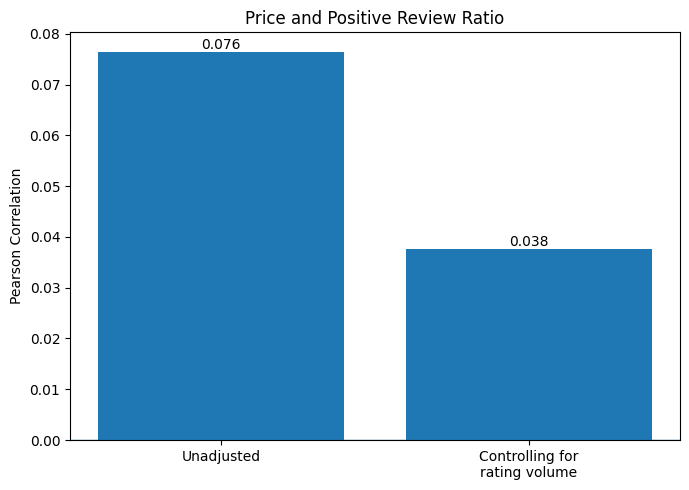

In [10]:
results = pd.DataFrame(
    {
        "relationship": [
            "Unadjusted",
            "Controlling for\nrating volume",
        ],
        "correlation": [
            overall_r,
            partial_r,
        ],
    }
)


fig, ax = plt.subplots(
    figsize=(7, 5)
)

bars = ax.bar(
    results["relationship"],
    results["correlation"],
)

ax.axhline(
    0,
    linewidth=1,
)

ax.set_title(
    "Price and Positive Review Ratio"
)

ax.set_ylabel(
    "Pearson Correlation"
)


for bar, value in zip(
    bars,
    results["correlation"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.3f}",
        ha="center",
        va="bottom",
    )


plt.tight_layout()
plt.show()

## Conclusion

The overall correlation between listed game price and positive review ratio is weakly positive (**r ≈ 0.076**).

However, rating volume is associated with both price and positive review ratio. After accounting for total rating volume, the relationship decreases to approximately **r ≈ 0.038**.

The apparent positive relationship between higher prices and better user ratings is therefore substantially weaker after accounting for differences in rating volume.